# PV Design Toolkit

### 0. Import dependencies 

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

### 1. Important parameters from PV Panel datasheets
There are about 93 manufacturers in India, registered under the list of Approved List of Models and Manufacturers (ALMM). Note that for to be eligible for getting registered under this ALMM list, one requires their minimum panel efficiency $\eta$ as per the application as listed in the table below: 

| Category | Application | Minimum $\eta$ for c-Si Technology | Minimum $\eta$ for CdTe Technology  |
|----------|----------|----------|-----------|
| I    | Utility/Grid Scale Power Plants     | 20.00%  | 19.00%   |
| II    | Rooftop and Solar Pumping     | 19.50%  | 18.50%   |
| III    | Off-grid projects less than 200W peak    | 18.00%  | 18.00%   |
| IV    | Other     | 19.00%  | 18.00%   |

Using diode equivalent circuit, the following relation is used to obtain the open-circuit voltage using short-circuit current values:  
$$
V_{\text{oc}} = \frac{kT}{q} \log\left({\frac{I_{\text{sc}}}{I_o} + 1}\right)
$$

where $I_o \approx 10^{-12} A/cm^2$ (typically) is the reverse saturation current, $q = 1.602 \times 10^{-19} C$ electron charge, $k = 1.381\times 10^{-23} J/K$ is the Boltzmann's constant and $T$ is the diode junction temperature. 


Consider the attached datasheet in this project. Check the electrical characteristic table and consider here the first model--WSMD-515. 

In [2]:
# verify the efficiency of WSD-515 module 
eta_datasheet = 20.01 

# maximum power point Voltage 
V_mpp_V = 40.99 

# maximum power point Current 
I_mpp_A = 12.57

# maximum power point 
P_max_W = V_mpp_V * I_mpp_A 

# now, from the mechanical characteristics table
length_module_m = 2.272 
width_module_m = 1.133
A_module_sqm = length_module_m * width_module_m

# STC considers the irradiance 
irr_wpm2 = 1000 

# Input Power 
P_in_W = A_module_sqm * irr_wpm2 

# A. module efficiency  
eta = P_max_W / P_in_W * 100
print(f"Module Efficiency = {eta:.2f}")

# short circuit current 
I_sc_A = 13.49 

# open circuit voltage
V_oc_V = 48.86 

# fill factor 
fill_factor = P_max_W / (I_sc_A * V_oc_V)

print(f"Fill-factor = {fill_factor:.2f}; a fill factor close to 1 is better.")


Module Efficiency = 20.02
Fill-factor = 0.78; a fill factor close to 1 is better.


### Estimating the Incident Energy $H (\text{kWh}/\text{m}^2/\text{day})$

Factors affecting: 
1. Geographic location ($\Phi$: latitude and $\lambda$: longitude)
2. Collector Orientation ($\beta$: collector tilt angle)
3. Time of day ($\omega$: hour angle)
4. Time of year ($\delta$: declination)
5. Atmospheric Conditions (indeterministic) ($k_T$: clearness index etc.)

In [3]:
# day of the year (N=1 is Jan 1st and N = 365 Dec 31st)
N = 80
delta = 23.45 * np.sin(2 * np.pi * (N - 80) / 356) * np.pi / 180 # radians 

print(f"Declination on {N}th day of the year is {(delta * 180 / np.pi):.2f} degrees.")

# empirical relation to determine the extraterrestrial insolation on a given day in a year 
L_sc = 1.37 # kW/m^2 (called the mean solar constant)
L_extra_terr = L_sc * (1 + 0.033 * np.cos( 360 * N / 365 * np.pi / 180) )

print(f"Extra-terrestrial insolation on {N}th day is {L_extra_terr:.2f} kWh/m^2")

# Latitude of the locality
phi = 51.54021 * np.pi / 180 # radians 
# sunrise angle 
omega_sr = np.acos( - np.tan(delta) * np.tan(phi)) # radians
# sunset angle 
omega_ss = - omega_sr # radians
print(f"The sunrise angle is {(omega_sr* 180 / np.pi):.2f} degrees.")

# day length  
day_length = 2 * 12 / np.pi * omega_sr # hours 

print(f"Day length is {day_length:.2f} hours.")

Declination on 80th day of the year is 0.00 degrees.
Extra-terrestrial insolation on 80th day is 1.38 kWh/m^2
The sunrise angle is 90.00 degrees.
Day length is 12.00 hours.


#### Incident energy $H_o$ for horizontal panel

In [4]:
# When the panel is horizontal 
H_o = 24 * L_extra_terr / np.pi * ( np.cos(phi) * np.cos(delta) * np.sin(omega_sr) + omega_sr * np.sin(phi) * np.sin(delta) ) # kWh/m^2/day
print(f"The incident energy on the horizontal flat PV panel is {H_o:.2f} kWh/m^2/day")

The incident energy on the horizontal flat PV panel is 6.55 kWh/m^2/day


#### Incident energy $H_{\text{ot}}$ for tilted panel

In [5]:
# tilt angle 
beta = 30 * np.pi / 180 

# incident energy with tilted panel 
omega_srbeta = np.acos( - np.tan(delta) * np.tan(phi - beta)) # radians 
omega_srt = np.min ( [omega_sr, omega_srbeta] )
H_ot = 24 * L_extra_terr / np.pi * (np.cos(phi - beta) * np.cos(delta) * np.sin(omega_srt) + omega_srt * np.sin(phi - beta) * np.sin(delta) ) # kWh/m^2/day
print(f"The incident energy on the tilted flat PV panel is {H_ot:.2f} kWh/m^2/day")

The incident energy on the tilted flat PV panel is 9.80 kWh/m^2/day


#### Profile of $H_o$ vs. $H_{ot}$ for a given latitude

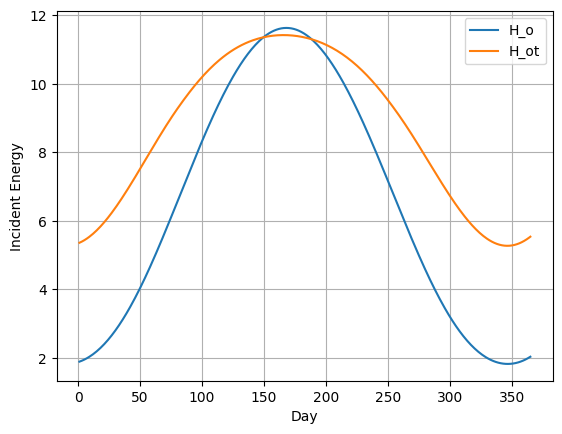

In [6]:
# a very lazy implementation
H_o_for_year = np.zeros((365,))
day_length_for_year = np.zeros((365,))
beta_i = 12.97 # (Bangalore)
H_ot_for_year = np.zeros((365,))
day_in_year = np.arange(0,365,1)+1

for N_i in np.arange(1,366,1):
    delta = 23.45 * np.sin(2 * np.pi * (N_i - 80) / 356) * np.pi / 180 # radians 
    # empirical relation to determine the extraterrestrial insolation on a given day in a year 
    L_sc = 1.37 # kW/m^2 (called the mean solar constant)
    L_extra_terr = L_sc * (1 + 0.033 * np.cos( 360 * N_i / 365 * np.pi / 180) )

    # sunrise angle 
    omega_sr = np.acos( - np.tan(delta) * np.tan(phi)) # radians
    # sunset angle 
    omega_ss = - omega_sr # radians

    # day length  
    day_length_for_year[N_i - 1] = 2 * 12 / np.pi * omega_sr # hours 

    H_o_for_year[N_i-1] = 24 * L_extra_terr / np.pi * ( np.cos(phi) * np.cos(delta) * np.sin(omega_sr) + omega_sr * np.sin(phi) * np.sin(delta) ) # kWh/m^2/day

    # incident energy with tilted panel 
    omega_srbeta = np.acos( - np.tan(delta) * np.tan(phi - beta_i)) # radians 
    omega_srt = np.min ( [omega_sr, omega_srbeta] )
    H_ot_for_year[N_i-1] = 24 * L_extra_terr / np.pi * (np.cos(phi - beta_i) * np.cos(delta) * np.sin(omega_srt) + omega_srt * np.sin(phi - beta_i) * np.sin(delta) ) # kWh/m^2/day


sns.lineplot(x=day_in_year, y=H_o_for_year, label='H_o')
sns.lineplot(x=day_in_year, y=H_ot_for_year, label='H_ot')
plt.xlabel('Day')
plt.ylabel('Incident Energy')
plt.grid()
plt.legend()
plt.show()

#### Determine the optimal tilt angle $\beta$

In [7]:
# a very lazy implementation
H_o_for_year = np.zeros((365,))
day_length_for_year = np.zeros((365,))
beta_range = np.arange(0,30,1) * np.pi/180
H_ot_for_year = np.zeros((365,))
day_in_year = np.arange(0,365,1)+1
H_ot_ripple_for_year = np.zeros_like(beta_range)
ripple_dict = {}

for i, beta_i in enumerate(beta_range):
    for N_i in np.arange(1,366,1):
        delta = 23.45 * np.sin(2 * np.pi * (N_i - 80) / 356) * np.pi / 180 # radians 
        # empirical relation to determine the extraterrestrial insolation on a given day in a year 
        L_sc = 1.37 # kW/m^2 (called the mean solar constant)
        L_extra_terr = L_sc * (1 + 0.033 * np.cos( 360 * N_i / 365 * np.pi / 180) )

        # sunrise angle 
        omega_sr = np.acos( - np.tan(delta) * np.tan(phi)) # radians
        # sunset angle 
        omega_ss = - omega_sr # radians

        # day length  
        day_length_for_year[N_i - 1] = 2 * 12 / np.pi * omega_sr # hours 

        H_o_for_year[N_i-1] = 24 * L_extra_terr / np.pi * ( np.cos(phi) * np.cos(delta) * np.sin(omega_sr) + omega_sr * np.sin(phi) * np.sin(delta) ) # kWh/m^2/day

        # incident energy with tilted panel 
        omega_srbeta = np.acos( - np.tan(delta) * np.tan(phi - beta_i)) # radians 
        omega_srt = np.min ( [omega_sr, omega_srbeta] )
        H_ot_for_year[N_i-1] = 24 * L_extra_terr / np.pi * (np.cos(phi - beta_i) * np.cos(delta) * np.sin(omega_srt) + omega_srt * np.sin(phi - beta_i) * np.sin(delta) ) # kWh/m^2/day

    H_ot_ripple_for_year[i] = np.max(H_ot_for_year) - np.min(H_ot_for_year)
    print(f"At tilt-angle {beta_i * (180 / np.pi):.2f} the H_ot ripple is {H_ot_ripple_for_year[i]:.2f} kWh/m^2/day.")

At tilt-angle 0.00 the H_ot ripple is 9.81 kWh/m^2/day.
At tilt-angle 1.00 the H_ot ripple is 9.66 kWh/m^2/day.
At tilt-angle 2.00 the H_ot ripple is 9.51 kWh/m^2/day.
At tilt-angle 3.00 the H_ot ripple is 9.36 kWh/m^2/day.
At tilt-angle 4.00 the H_ot ripple is 9.21 kWh/m^2/day.
At tilt-angle 5.00 the H_ot ripple is 9.06 kWh/m^2/day.
At tilt-angle 6.00 the H_ot ripple is 8.91 kWh/m^2/day.
At tilt-angle 7.00 the H_ot ripple is 8.76 kWh/m^2/day.
At tilt-angle 8.00 the H_ot ripple is 8.61 kWh/m^2/day.
At tilt-angle 9.00 the H_ot ripple is 8.45 kWh/m^2/day.
At tilt-angle 10.00 the H_ot ripple is 8.30 kWh/m^2/day.
At tilt-angle 11.00 the H_ot ripple is 8.14 kWh/m^2/day.
At tilt-angle 12.00 the H_ot ripple is 7.98 kWh/m^2/day.
At tilt-angle 13.00 the H_ot ripple is 7.82 kWh/m^2/day.
At tilt-angle 14.00 the H_ot ripple is 7.66 kWh/m^2/day.
At tilt-angle 15.00 the H_ot ripple is 7.50 kWh/m^2/day.
At tilt-angle 16.00 the H_ot ripple is 7.34 kWh/m^2/day.
At tilt-angle 17.00 the H_ot ripple is 7.

In [8]:
print(f"Lowest ripple (therefore, optimal) is at tilt angle = {np.argmin(H_ot_ripple_for_year)} degrees.")

Lowest ripple (therefore, optimal) is at tilt angle = 29 degrees.
